
Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_18972\689089502.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


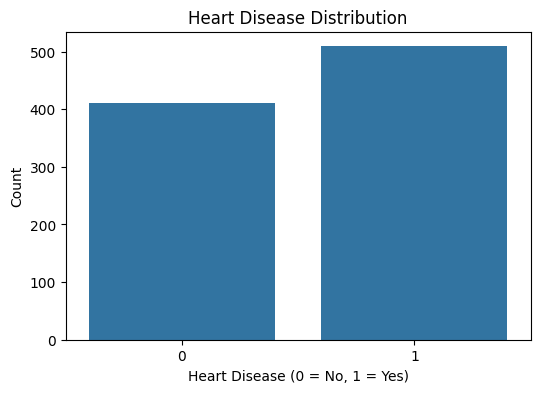

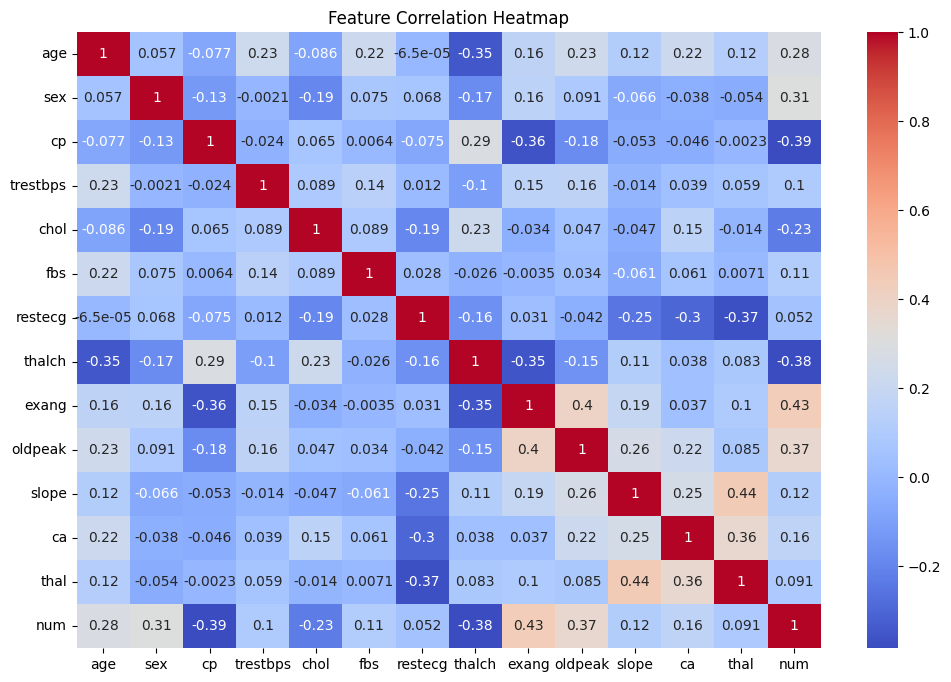


Accuracy: 0.7880434782608695

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76        75
           1       0.87      0.75      0.81       109

    accuracy                           0.79       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.79      0.79       184



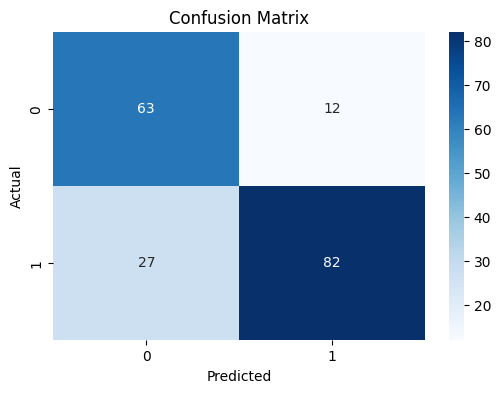

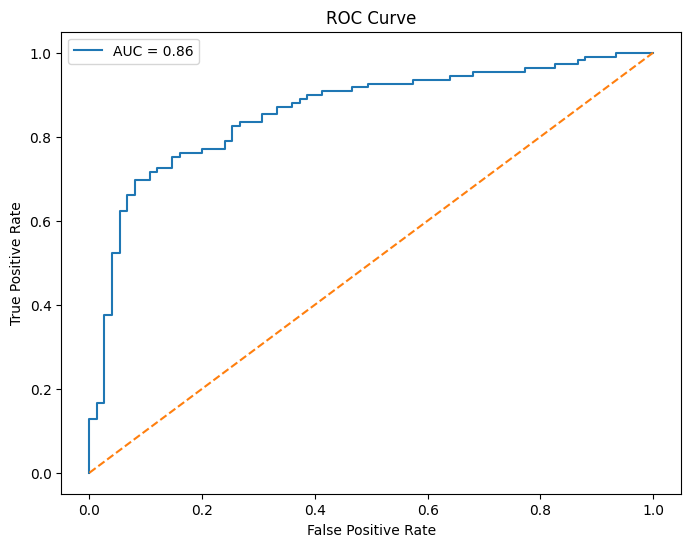


ROC-AUC Score: 0.8594495412844038

Feature Importance:
     Feature  Importance
1        sex    1.540839
8      exang    1.030109
11        ca    0.809369
9    oldpeak    0.664309
5        fbs    0.520142
6    restecg    0.164593
12      thal    0.078598
0        age    0.014380
3   trestbps    0.001752
4       chol   -0.005031
7     thalch   -0.016869
10     slope   -0.042787
2         cp   -0.645769


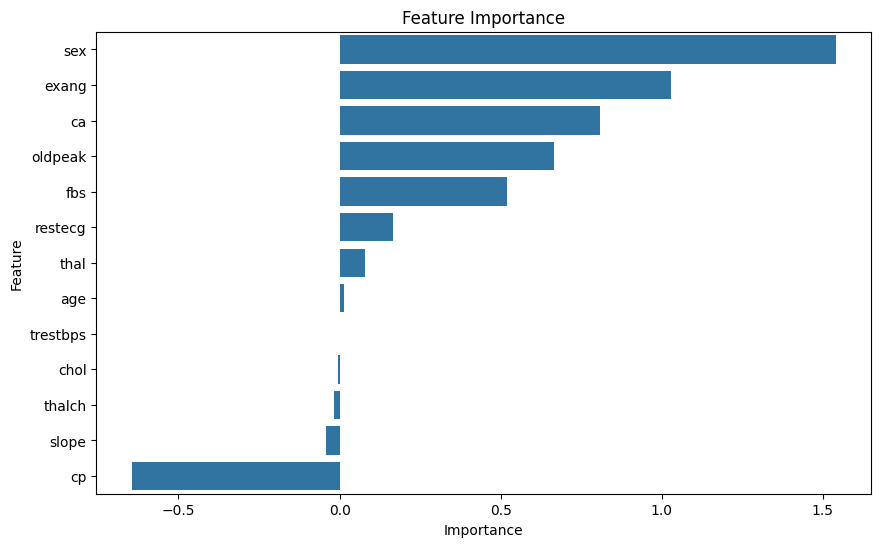

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

data = pd.read_csv("heart_disease_uci.csv")

data = data.drop(columns=['id', 'dataset'])

data['num'] = (data['num'] > 0).astype(int)

data['sex'] = (data['sex'] == 'Male').astype(int)

data['fbs'] = data['fbs'].fillna(0).astype(int)
data['exang'] = data['exang'].fillna(0).astype(int)

for col in data.select_dtypes(include='object').columns:
    data[col] = pd.Categorical(data[col]).codes

data = data.fillna(data.median(numeric_only=True))

print("\nMissing Values:")
print(data.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(x='num', data=data)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

X = data.drop('num', axis=1)
y = data['num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\nROC-AUC Score:", roc_auc)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

